# 02 — Control Theory: Controllability, Feedback, LQR and MPC

**Mathematical Foundations of Control and Machine Learning — Winter 2026**

In this notebook, we explore the field of control theory, which is concerned with the design of inputs to dynamical systems in order to achieve desired behaviors.

### Table of Contents

1. **A short history** — from Watt's governor to model predictive control
2. **The linear model** — LTI systems and a spring–mass–damper
3. **Controllability** — the Kalman rank condition, with proof, and the Gramian steering law
4. **State feedback** — how the gain changes the closed-loop dynamics
5. **LQR** — letting a cost function choose the poles; the Riccati equation
6. **The nonlinear case** — model predictive control, and a pendulum that a linear law cannot lift
7. **What we left out** — observability, duality, and the road to reinforcement learning

In [1]:
%matplotlib inline
import numpy as np
import torch
import matplotlib.pyplot as plt
import plotting as P           # the course palette, the house style, and the figure helpers

torch.manual_seed(0)

In [2]:
# RK4 integrator for x' = f(t, x) along the time grid ts (derived in notebook 04; a black box here)
def odeint(f, x0, ts):
    xs = [x0]
    for t, t1 in zip(ts[:-1], ts[1:]):
        x, h = xs[-1], t1 - t
        k1 = f(t, x)
        k2 = f(t + h / 2, x + h / 2 * k1)
        k3 = f(t + h / 2, x + h / 2 * k2)
        k4 = f(t + h, x + h * k3)
        xs.append(x + h / 6 * (k1 + 2 * k2 + 2 * k3 + k4))
    return torch.stack(xs)

## 1. A short history

**Idea.** Feedback adjusts an input after observing what the system does.

Feedback devices are much older than the theory that explains them. In the third century BCE, [Ktesibios’s water clock](https://collection.kotsanasmuseum.com/en/exhibits/106045/) used a float valve to keep its water supply steady. [Windmills used fantails](https://millsarchive.org/2016/09/06/from-quern-to-computer-the-history-of-flour-milling/9/) to turn into the wind automatically. In 1788, [James Watt fitted a centrifugal governor to a steam engine](https://collection.sciencemuseumgroup.org.uk/objects/co50948/rotative-steam-engine-by-boulton-and-watt-1788): as two rotating balls moved outward, they adjusted a valve that controlled the steam supply. These devices worked, but a general mathematical account of their stability came later.

![Illustration of a centrifugal governor](images/governor_maxwell.png)


By the 1860s, engineers faced a practical problem: making a governor more responsive could cause it to oscillate, or *hunt*. In [*On Governors* (1868)](https://doi.org/10.1098/rspl.1867.0055), James Clerk Maxwell described small departures from steady operation with linear differential equations. He related stability to the roots of a characteristic polynomial: disturbances die away when every root has a negative real part.

In the 1950s and early 1960s, [Bellman’s dynamic programming](https://doi.org/10.1090/S0002-9904-1954-09848-8), [Pontryagin’s maximum principle](https://www.mathnet.ru/eng/im3547), and [Kalman’s work on optimal control](https://liberzon.csl.illinois.edu/teaching/kalman_paper.pdf) helped establish modern state-space control. Kalman developed the concepts of **controllability** and **observability** and analyzed the linear–quadratic regulator using a Riccati equation. His [1960 paper on filtering](https://doi.org/10.1115/1.3662552) addressed a different task: estimating a system’s state from noisy measurements. Kalman filtering was later used in [Apollo’s onboard navigation](https://web.mit.edu/digitalapollo/Documents/Chapter5/mitroleapollovi.pdf).

## 2. The linear model

**Idea.** State variables turn a mechanical equation into a matrix ODE.

Consider the **linear time-invariant** (LTI) system

$$
\dot x(t) = A x(t) + B u(t), \qquad x(t) \in \mathbb{R}^n, \quad u(t) \in \mathbb{R}^m,
$$

with constant matrices $A \in \mathbb{R}^{n \times n}$ and $B \in \mathbb{R}^{n \times m}$. The vector
$x(t)$ is the **state** and $u(t)$ is the **input**.

> **Example (the spring–mass–damper).**
> A mass $m$ is attached to a spring of stiffness $k$ and a damper of coefficient $c$. We measure displacement $q$ from equilibrium and apply a force $u(t)$. 
>
> Newton's second law reads $m\ddot q = -kq - c\dot q + u$. Writing $x = (x_1, x_2)^\top$ with $x_1 = q$ the position and $x_2 = \dot q$ the velocity turns one second-order equation into two first-order ones:
> $$ \begin{bmatrix} \dot x_1 \\ \dot x_2 \end{bmatrix} = \underbrace{\begin{bmatrix} 0 & 1 \\ -\tfrac{k}{m} & -\tfrac{c}{m} \end{bmatrix}}_{A}   \begin{bmatrix} x_1 \\ x_2 \end{bmatrix} + \underbrace{\begin{bmatrix} 0 \\ \tfrac{1}{m} \end{bmatrix}}_{B} u . $$

**Code and plot.** Draw the mechanical system, then plot its position and velocity with no input.

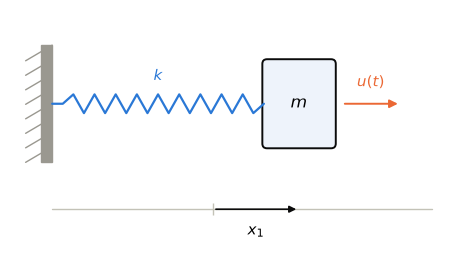

In [3]:
fig, ax = P.panels(figsize=(6.2, 2.8))
P.spring_mass_damper(ax, pos=1.1)
plt.show()

eigenvalues of A: [-0.25+0.9682j -0.25-0.9682j]


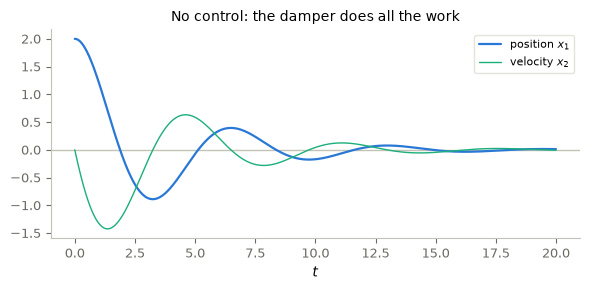

In [4]:
m, k, c = 1.0, 1.0, 0.5
A = torch.tensor([[0.0, 1.0], [-k / m, -c / m]])
B = torch.tensor([[0.0], [1.0 / m]])

def lti(A, B, u):
    """Right-hand side of x' = Ax + Bu, with u a callable u(t, x) -> R^m."""
    return lambda t, x: A @ x + B @ u(t, x)

x0 = torch.tensor([2.0, 0.0])                       # released from rest, 2 units off equilibrium
ts = torch.linspace(0, 20, 401)

free = odeint(lti(A, B, lambda t, x: torch.zeros(1)), x0, ts)

print("eigenvalues of A:", np.round(torch.linalg.eigvals(A).numpy(), 4))

fig, ax = P.panels(figsize=(6, 3))
P.curves(ax, ts, {"position $x_1$": (free[:, 0], P.BLUE),
                "velocity $x_2$": (free[:, 1], {"color": P.AQUA, "lw": 1})},
       xlabel="$t$", zero="h", title="No control: the damper does all the work")
plt.show()

The eigenvalues have negative real part, so the mass rings down to the origin on its
own. That is a statement about where the system *goes*, not about where we can *send* it. Two questions
follow immediately:

- **Existence.** Given a target $x_{\text{target}}$ and a horizon $T > 0$, is there an input $u(\cdot)$
  steering $x(0) = x_0$ to $x(T) = x_{\text{target}}$?
- **Construction.** If there is one, can we write it down — and can we pick a good one?

For finite-dimensional LTI systems both have clean answers, and they are the content of the next section.

## 3. Controllability: the Kalman rank condition

**Idea.** Check which directions the input and dynamics can reach together.

> **Definition (controllability).** The pair $(A,B)$ is **controllable** if for every $x_0, x_f \in \mathbb{R}^n$ and every
> $T > 0$ there exists an input $u(\cdot)$ such that
> $$ x(0) = x_0 \quad\text{and}\quad x(T) = x_f. $$

> **Theorem ([Kalman, 1960](https://liberzon.csl.illinois.edu/teaching/kalman_paper.pdf)).** The pair $(A,B)$ is **controllable** if and only if the **controllability matrix**
> $$ \mathcal{C} = \big[\, B \;\big|\; AB \;\big|\; A^2 B \;\big|\; \cdots \;\big|\; A^{n-1}B \,\big]
>    \in \mathbb{R}^{n \times nm} $$
> has rank $n$.

The columns of $\mathcal{C}$ are the directions the input can push in ($B$), together with the directions
those get rotated into by the drift ($AB$, $A^2B$, …).

**Code and plot.** Compute the controllability matrix for one oscillator and for two oscillators sharing an input.

In [5]:
def ctrb(A, B):
    """Kalman controllability matrix [B | AB | ... | A^{n-1}B]."""
    cols = [B]
    for _ in range(A.shape[0] - 1):
        cols.append(A @ cols[-1])
    return torch.cat(cols, dim=1)

def controllable(A, B, tol=1e-9):
    s = torch.linalg.svdvals(ctrb(A, B))
    return bool((s > tol * s[0]).sum() == A.shape[0]), s

ok, s = controllable(A, B)
print("spring-mass-damper:  C =\n", ctrb(A, B).numpy())
print(f"  singular values {np.round(s.numpy(), 4)}  ->  controllable: {ok}")

spring-mass-damper:  C =
 [[ 0.   1. ]
 [ 1.  -0.5]]
  singular values [1.2808 0.7808]  ->  controllable: True


In [6]:
# A system that FAILS the test: two oscillators driven by one shared force.
def two_oscillators(w1, w2):
    A = torch.tensor([[0., 1., 0., 0.], [-w1**2, 0., 0., 0.],
                      [0., 0., 0., 1.], [0., 0., -w2**2, 0.]])
    B = torch.tensor([[0.], [1.], [0.], [1.]])         # the same force acts on both masses
    return A, B

for w2 in [1.0, 1.3]:
    A2, B2 = two_oscillators(1.0, w2)
    ok, s = controllable(A2, B2)
    print(f"w1 = 1.0, w2 = {w2}:  rank C = {int((s > 1e-9 * s[0]).sum())} / 4  ->  controllable: {ok}")

# When the two frequencies coincide, the difference of the positions is untouchable.
A2, B2 = two_oscillators(1.0, 1.0)
q = torch.tensor([1.0, 0.0, -1.0, 0.0])                # q = "x1 - x3"
print("\nq^T A^k B for k = 0..3:", [round(float(q @ torch.linalg.matrix_power(A2, kk) @ B2), 12)
                                   for kk in range(4)])

w1 = 1.0, w2 = 1.0:  rank C = 3 / 4  ->  controllable: False
w1 = 1.0, w2 = 1.3:  rank C = 4 / 4  ->  controllable: True

q^T A^k B for k = 0..3: [0.0, 0.0, 0.0, 0.0]


### Optional derivation

#### 3.1 Why the condition is necessary

Variation of constants gives the solution

$$ x(T) = e^{AT} x_0 + \int_0^T e^{A(T-s)} B\, u(s)\, ds . $$

The first term does not involve $u$, so controllability is a statement about the **reachable set from the
origin**, $\;\mathcal{R}_T = \big\{\int_0^T e^{A(T-s)}B\,u(s)\,ds \;:\; u(\cdot) \text{ admissible}\big\}$.

Suppose $\operatorname{rank}\mathcal{C} < n$. Then the rows of $\mathcal{C}$ are dependent: there is
$q \neq 0$ with

$$ q^\top A^k B = 0, \qquad k = 0, 1, \dots, n-1, $$

and by Cayley–Hamilton the same holds for *every* $k \ge 0$. Since
$e^{A\tau} = \sum_{k\ge0} \frac{\tau^k}{k!}A^k$,

$$ q^\top e^{A\tau} B = \sum_{k \ge 0} \frac{\tau^k}{k!}\, q^\top A^k B = 0 \qquad \text{for all } \tau \ge 0 ,$$

and therefore, for every admissible input,

$$ q^\top \!\! \int_0^T e^{A(T-s)}B\,u(s)\,ds = \int_0^T \big(q^\top e^{A(T-s)}B\big)u(s)\,ds = 0 .$$

The scalar $q^\top x(T) = q^\top e^{AT}x_0$ is the same for every control we could possibly apply. The
reachable set lies in a hyperplane, so the system is not controllable.

#### 3.2 Why it is sufficient

Define the **controllability Gramian**

$$ W(T) \;:=\; \int_0^T e^{A\tau} B B^\top e^{A^\top \tau}\, d\tau \;\in\; \mathbb{R}^{n\times n},
\qquad W(T) = W(T)^\top \succeq 0 .$$

Let $d = x_{\text{target}} - e^{AT}x_0$ be the displacement we must produce. Among all controls achieving
it, look for the one of least energy, $J(u) = \tfrac12\int_0^T \|u(s)\|^2\,ds$. With a Lagrange multiplier
$\lambda \in \mathbb{R}^n$ for the terminal constraint,

$$ \mathcal{L}(u,\lambda) = \tfrac12\int_0^T \! u^\top u \, ds
   + \lambda^\top\Big( \int_0^T \! e^{A(T-s)}B\,u(s)\,ds - d \Big) .$$

Stationarity in $u$, pointwise in $s$, gives $u(s) = -B^\top e^{A^\top (T-s)}\lambda$. Substituting into the
constraint and changing variables $\tau = T-s$,

$$ d = -\int_0^T e^{A(T-s)} B B^\top e^{A^\top (T-s)}\,ds\;\lambda = -W(T)\lambda .$$

So *if $W(T)$ is invertible*, then $\lambda = -W(T)^{-1}d$ and

$$ \boxed{\; u^\star(s) = B^\top e^{A^\top (T-s)}\, W(T)^{-1} d \;}
\qquad\text{with}\qquad \int_0^T \|u^\star(s)\|^2 ds = d^\top W(T)^{-1} d .$$

The energy $d^\top W(T)^{-1} d$ is the honest price of the maneuver: directions in which $W(T)$ is nearly
singular are the expensive ones, even when the rank test formally passes.


> **Note — invertibility of $W(T)$ *is* the rank condition.**
>
> ($\Rightarrow$) If $\operatorname{rank}\mathcal{C} < n$, take $q\neq0$ as in §3.1; then
> $B^\top e^{A^\top\tau}q \equiv 0$ and
> $$ q^\top W(T) q = \int_0^T \big\| B^\top e^{A^\top \tau} q \big\|^2 d\tau = 0, $$
> so $W(T)$ is singular for every $T>0$.
>
> ($\Leftarrow$) Conversely, if $W(T)$ were singular there would be $q \neq 0$ with $q^\top W(T)q = 0$,
> hence $B^\top e^{A^\top \tau}q \equiv 0$ on $[0,T]$. Differentiating repeatedly at $\tau = 0$ yields
> $B^\top (A^\top)^k q = 0$, i.e. $q^\top A^k B = 0$, for all $k \ge 0$ — contradicting
> $\operatorname{rank}\mathcal{C} = n$. Note this also proves that controllability holds for **every**
> horizon $T > 0$, however small: a linear system has no minimum maneuver time. It pays for haste in
> energy instead, since $W(T)^{-1}$ blows up as $T \to 0$.

**Code and plot.** Compute the Gramian steering law and compare its endpoint with the target.

In [7]:
def gramian(A, B, T, n_quad=400):
    """W(T) = ∫_0^T e^{Aτ} B Bᵀ e^{Aᵀτ} dτ, by the trapezoid rule."""
    taus = torch.linspace(0, T, n_quad + 1)
    integrand = torch.stack([(E := torch.matrix_exp(A * tau)) @ B @ B.T @ E.T for tau in taus])
    return torch.trapezoid(integrand, taus, dim=0)

class MinEnergyControl:
    """u*(t) = Bᵀ e^{Aᵀ(T-t)} W(T)⁻¹ (x_target - e^{AT} x₀)   — open loop."""
    def __init__(self, A, B, x0, x_target, T):
        self.A, self.B, self.T = A, B, T
        self.W = gramian(A, B, T)
        self.d = x_target - torch.matrix_exp(A * T) @ x0
        self.lam = torch.linalg.solve(self.W, self.d)

    def __call__(self, t, x):
        return self.B.T @ torch.matrix_exp(self.A.T * (self.T - t)) @ self.lam

    def energy(self):
        return float(self.d @ self.lam)

T = 8.0
x_target = torch.tensor([1.0, 1.0])
u_star = MinEnergyControl(A, B, x0, x_target, T)

ts_T = torch.linspace(0, T, 801)
steered = odeint(lti(A, B, u_star), x0, ts_T)

print("W(T) =\n", np.round(u_star.W.numpy(), 4), "   cond =", round(float(torch.linalg.cond(u_star.W)), 3))
print(f"reached  x(T) = {np.round(steered[-1].numpy(), 6)}   target = {x_target.numpy()}")
print(f"control energy ∫‖u*‖² dt = dᵀW⁻¹d = {u_star.energy():.4f}")

W(T) =
 [[0.9783 0.0096]
 [0.0096 0.9803]]    cond = 1.02
reached  x(T) = [1.000044 0.999986]   target = [1. 1.]
control energy ∫‖u*‖² dt = dᵀW⁻¹d = 2.4735


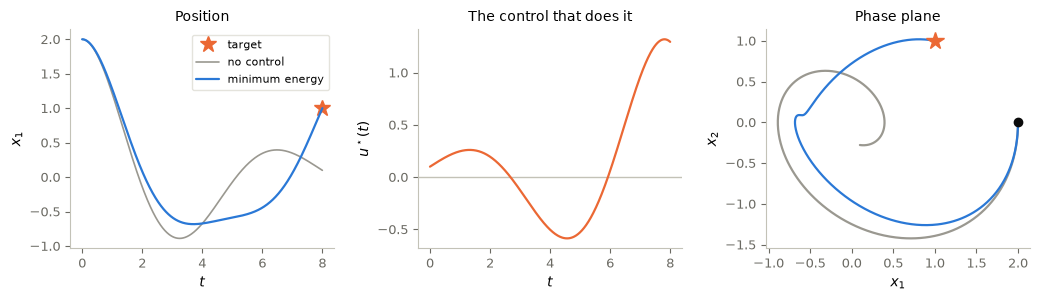

In [8]:
us = torch.stack([u_star(t, None) for t in ts_T]).squeeze(-1)
free_T = odeint(lti(A, B, lambda t, x: torch.zeros(1)), x0, ts_T)

fig, axs = P.panels(3, size=(3.5, 3.1))
axs[0].plot(T, x_target[0], "*", color=P.ORANGE, ms=12, label="target")
P.curves(axs[0], ts_T, {"no control": (free_T[:, 0], {"color": P.GREY, "lw": 1.2}),
                      "minimum energy": (steered[:, 0], P.BLUE)},
       xlabel="$t$", ylabel="$x_1$", title="Position")
P.curves(axs[1], ts_T, (us, P.ORANGE), xlabel="$t$", ylabel=r"$u^\star(t)$", zero="h",
       title="The control that does it")
P.phase(axs[2], [free_T, steered], colors=[P.GREY, P.BLUE], start=x0, target=x_target,
      xlabel="$x_1$", ylabel="$x_2$", title="Phase plane")
plt.show()

In [9]:
idx = torch.arange(0, len(ts_T), 16)                # ~50 frames
pf, pc = free_T[idx, 0].numpy(), steered[idx, 0].numpy()

fig, (axm, axt) = P.panels(1, 2, ratios=[1.1, 1], figsize=(6.4, 4.6))
up_free = P.spring_mass_artist(axm, 0.8, P.GREY, "no control")
up_ctrl = P.spring_mass_artist(axm, -0.8, P.BLUE, "$u^\\star$")
axm.plot(x_target[0], -0.8, "*", color=P.ORANGE, ms=14, zorder=0)
P.label(axm, xlim=(-3.2, 2.7), ylim=(-1.8, 1.8), equal=True, off=True)

axt.plot(ts_T, free_T[:, 0], color=P.GREY, lw=1.2)
axt.plot(ts_T, steered[:, 0], color=P.BLUE, lw=1.5)
axt.plot(T, x_target[0], "*", color=P.ORANGE, ms=12)
cursor = axt.axvline(0, color=P.ORANGE, lw=1)
P.label(axt, "$t$", "$x_1$", xlim=(0, T))

def update(i):
    up_free(pf[i]); up_ctrl(pc[i]); cursor.set_xdata([ts_T[idx[i]]] * 2)

P.animate(fig, update, len(idx), interval=60)

## 4. State feedback

**Idea.** Choose the input from the state you measure now.

The control $u^\star$ we just built is **open loop**. It is a function of time alone, computed once from
$x_0$ and then played back with the eyes closed. Nudge the mass halfway through, or get $k$ slightly wrong,
and it misses.

The alternative is **state feedback**: measure $x(t)$ and decide the input from it,

$$ u(t) = -K x(t), \qquad K \in \mathbb{R}^{m \times n}, $$

which turns the open-loop system into the autonomous closed-loop system

$$ \dot x = (A - BK)\,x . $$

Design is now a spectral question, as [Maxwell framed it in 1868](https://doi.org/10.1098/rspl.1867.0055): choose $K$ so that the eigenvalues
of $A - BK$ sit where we want them. Real part $<0$ means the state decays.

**Code and plot.** Read the feedback diagram as a loop from state measurement to input and back.

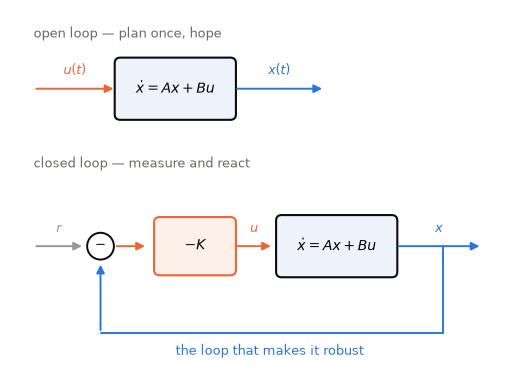

In [10]:
fig, ax = P.panels(figsize=(6.8, 4.0))
P.feedback_diagram(ax)
plt.show()

## 5. Linear quadratic regulator

**Idea.** Balance state error and input effort through a quadratic cost.

The **linear quadratic regulator** problem is

$$ \min_{u(\cdot)} \; J(u) = \int_0^\infty \Big( x(t)^\top Q\, x(t) + u(t)^\top R\, u(t) \Big) dt
\qquad \text{s.t.} \qquad \dot x = Ax + Bu, \;\; x(0)=x_0, $$

with $Q = Q^\top \succeq 0$ weighting how much we dislike being away from the origin and
$R = R^\top \succ 0$ weighting how much we dislike spending input. The ratio between them is the only
design knob, and it has units an engineer can reason about.

### Optional derivation: completing the square

Take any symmetric $P$ and consider the quantity $x^\top P x$ along a trajectory:

$$ \frac{d}{dt}\big(x^\top P x\big) = x^\top(A^\top P + PA)x + 2\,x^\top P B u .$$

If the control stabilizes the system then $x(t) \to 0$, so
$\int_0^\infty \frac{d}{dt}(x^\top Px)\,dt = -x_0^\top P x_0$. Adding zero in this form,

$$ J(u) = x_0^\top P x_0 + \int_0^\infty \Big[ x^\top\big(Q + A^\top P + PA\big)x + 2x^\top PBu + u^\top R u \Big] dt .$$

The bracket is a quadratic in $u$; complete the square using $R \succ 0$:

$$ u^\top R u + 2 x^\top P B u = \big\|u + R^{-1}B^\top P x\big\|_R^2 - x^\top P B R^{-1} B^\top P x ,$$

so that

$$ J(u) = x_0^\top P x_0
  + \int_0^\infty \Big[ x^\top \underbrace{\big(A^\top P + PA - PBR^{-1}B^\top P + Q\big)}_{\text{choose } P \text{ to kill this}} x
  \;+\; \big\|u + R^{-1}B^\top P x\big\|_R^2 \Big] dt .$$

Now **define** $P$ to be the symmetric positive semidefinite solution of the **algebraic Riccati equation**

$$ \boxed{\; A^\top P + P A - P B R^{-1} B^\top P + Q = 0 \;} $$

The first integrand vanishes identically and we are left with $J(u) = x_0^\top P x_0 + \int_0^\infty \|u + Kx\|_R^2\,dt$
with $K = R^{-1}B^\top P$. Every term is non-negative, so

$$ J(u) \;\ge\; x_0^\top P x_0 \quad\text{for all } u, \qquad\text{with equality iff}\qquad
   \boxed{\; u^\star(t) = -K x(t), \quad K = R^{-1}B^\top P .\;} $$

Two things follow immediately. The optimal control is a **linear state feedback**. The optimal cost is the quadratic form $V(x) = x^\top P x$, which is the **value function** of the problem and doubles as a Lyapunov function for the closed loop. 

The standard existence assumptions are **stabilizability** of $(A,B)$ and **detectability** of $(Q^{1/2},A)$ ([Åström and Murray, 2021](https://www.cds.caltech.edu/~murray/FBS/Second_Edition.html)). Controllability is a sufficient condition for stabilizability, but it is stronger than necessary. With $Q \succ 0$, an uncontrollable unstable mode gives infinite cost for initial states with a component in that mode.

### Solving the Riccati equation

The ARE is quadratic in $P$, so it has several solutions and we want the stabilizing one. The standard
route is the $2n \times 2n$ **Hamiltonian matrix**

$$ H = \begin{bmatrix} A & -BR^{-1}B^\top \\ -Q & -A^\top \end{bmatrix} ,$$

whose spectrum is symmetric about the imaginary axis. Take a basis $\begin{bmatrix}X_1\\X_2\end{bmatrix}$ of
the invariant subspace belonging to the $n$ eigenvalues with negative real part; then $P = X_2X_1^{-1}$.

**Code and plot.** Compute the LQR gain and compare the predicted optimal cost with the integrated trajectory cost.

In [11]:
def care(A, B, Q, R):
    """Stabilising solution of AᵀP + PA − PBR⁻¹BᵀP + Q = 0, via the Hamiltonian matrix."""
    n = A.shape[0]
    H = torch.cat([torch.cat([A, -B @ torch.linalg.solve(R, B.T)], dim=1),
                   torch.cat([-Q, -A.T], dim=1)], dim=0)
    w, V = torch.linalg.eig(H)
    stable = torch.argsort(w.real)[:n]                 # the n eigenvalues with Re < 0
    U = V[:, stable]
    return (U[n:] @ torch.linalg.inv(U[:n])).real

def lqr(A, B, Q, R):
    P = care(A, B, Q, R)
    return torch.linalg.solve(R, B.T @ P), P           # K, P


DESIGNS = [("slow  $-1 \\pm i$",      [-1 + 1j, -1 - 1j],  P.BLUE),
           ("medium  $-3, -4$",       [-3.0, -4.0],        P.AQUA),
           ("fast  $-6 \\pm 6i$",     [-6 + 6j, -6 - 6j],  P.ORANGE)]
ts_fb = torch.linspace(0, 8, 401)
op = torch.linalg.eigvals(A).numpy()

Q, R = torch.eye(2), torch.tensor([[1.0]])
K_lqr, P_lqr = lqr(A, B, Q, R)

residual = A.T @ P_lqr + P_lqr @ A - P_lqr @ B @ torch.linalg.solve(R, B.T @ P_lqr) + Q
print("P  =\n", np.round(P_lqr.numpy(), 4))
print("K  =", np.round(K_lqr.numpy().ravel(), 4))
print("ARE residual norm =", f"{float(residual.norm()):.2e}")
print("closed-loop poles =", np.round(torch.linalg.eigvals(A - B @ K_lqr).numpy(), 4))
print(f"\noptimal cost from x0:  x0ᵀ P x0 = {float(x0 @ P_lqr @ x0):.4f}")

traj_lqr = odeint(lti(A, B, lambda t, x: -K_lqr @ x), x0, ts_fb)
u_l = -(traj_lqr @ K_lqr.T).squeeze(-1)
J_num = torch.trapezoid(((traj_lqr @ Q) * traj_lqr).sum(-1) + u_l**2 * R[0, 0], ts_fb)
print(f"cost integrated along the trajectory  = {float(J_num):.4f}")

P  =
 [[1.5388 0.4142]
 [0.4142 0.9417]]
K  = [0.4142 0.9417]
ARE residual norm = 2.23e-06
closed-loop poles = [-0.7208+0.9458j -0.7208-0.9458j]

optimal cost from x0:  x0ᵀ P x0 = 6.1553
cost integrated along the trajectory  = 6.1554


The two numbers agree, which is the derivation checking itself: $x_0^\top P x_0$ really is the value of the
optimal cost.

Two more facts worth seeing numerically. First, the **finite-horizon** problem
$\int_0^T(x^\top Qx + u^\top Ru)\,dt + x(T)^\top Q_T x(T)$ has a *time-varying* solution
$u = -R^{-1}B^\top P(t)x$, where $P$ solves the **differential Riccati equation** backwards from the
terminal condition:

$$ -\dot P = A^\top P + PA - PBR^{-1}B^\top P + Q, \qquad P(T) = Q_T . $$

As the horizon grows, $P(t)$ settles onto the constant solution of the algebraic equation — the
infinite-horizon regulator is the long-horizon limit. Second, sweeping $R$ traces the closed-loop poles
along the **symmetric root locus**: for $R \to \infty$ (input is precious) they approach the stable
reflections of the open-loop poles, as $R \to 0$ (input is cheap), some poles move far left while others can approach finite limits. The exact behavior depends on the system.

Everything so far has rested on one assumption: the model is **linear**.

## 6. The nonlinear case: model predictive control

**Idea.** Plan ahead using the nonlinear model, then replan after the next measurement.

Real systems are of the form

$$ \dot x = f(x, u), \qquad u(t) \in \mathcal{U} \subset \mathbb{R}^m, $$

where $f$ is nonlinear and $\mathcal{U}$ is the set of admissible inputs. Nonlinear accessibility can involve Lie-bracket conditions, while controllability requires additional care. In the undiscounted infinite-horizon setting, the value function is described by the
Hamilton–Jacobi–Bellman PDE

$$ \min_{u \in \mathcal{U}} \Big\{ \ell(x,u) + \nabla V(x)^\top f(x,u) \Big\} = 0 , $$

which for $n$ more than a handful cannot be solved on a grid. LQR is the lucky special case where the HJB
equation has a finite-dimensional closed form.

**Model predictive control** takes the pragmatic route. Rather than solve for the feedback law $u = \pi(x)$
everywhere, solve a finite-horizon optimal control problem *at the state you are actually in*, numerically,
right now:

$$
\begin{aligned}
\min_{u(\cdot)} \;\; & \int_t^{t+T} \ell\big(x(s), u(s)\big)\, ds \;+\; V_f\big(x(t+T)\big) \\
\text{s.t.} \;\; & \dot x = f(x,u), \quad x(t) = \hat x(t), \quad u(s) \in \mathcal{U} .
\end{aligned}
$$

Then throw almost all of it away: apply only $u^\star$ on $[t, t + \Delta)$, measure the state again, and
re-solve from there. Planning far ahead but committing only to the next step is what turns an open-loop
plan into a feedback law. It is also what makes MPC tolerate the
model being slightly wrong.

> **The test problem: swinging up a pendulum**
>
> A bob of mass $M$ on a massless rod of length $L$ pivots freely, so its moment of inertia is $ML^2$. The angle $\theta$ is measured **from the upright**: $\theta = 0$ is the unstable equilibrium and $\theta = \pi$ is the pendulum hanging at rest. With a torque $u$ applied at the pivot, $ML^2\ddot\theta = MgL\sin\theta - b ML^2\dot\theta + u$, i.e.
> $$ \ddot\theta = \frac{g}{L}\sin\theta \;-\; b\,\dot\theta \;+\; \frac{u}{ML^2}, \qquad |u| \le u_{\max}. $$
>
> Linearising at the top ($\sin\theta \approx \theta$) gives
>
> $$ A = \begin{bmatrix} 0 & 1 \\ g/L & -b \end{bmatrix}, \qquad    B = \begin{bmatrix} 0 \\ 1/ML^2 \end{bmatrix} , $$


**Code and animation.** Apply the saturated law $u = \operatorname{sat}(-Kx)$, designed on the linearization, to the true nonlinear pendulum, started at rest from two nearby angles.

In [12]:
G, L_ROD, M_ROD, DAMP = 9.81, 1.0, 1.0, 0.10
U_MAX = 3.0                                    # M g L = 9.81, so we have well under a third of it

def f_pend(x, u):
    """x = (θ, ω) with θ measured from upright; u = torque. Batched over leading dims."""
    return torch.stack([x[..., 1],
                        (G / L_ROD) * torch.sin(x[..., 0]) - DAMP * x[..., 1]
                        + u[..., 0] / (M_ROD * L_ROD**2)], dim=-1)

def step_pend(x, u, h):                        # one RK4 step with a zero-order-hold input
    k1 = f_pend(x, u); k2 = f_pend(x + h/2 * k1, u)
    k3 = f_pend(x + h/2 * k2, u); k4 = f_pend(x + h * k3, u)
    return x + h / 6 * (k1 + 2*k2 + 2*k3 + k4)

wrap = lambda a: torch.remainder(a + np.pi, 2 * np.pi) - np.pi     # angle into (−π, π]

A_p = torch.tensor([[0.0, 1.0], [G / L_ROD, -DAMP]])
B_p = torch.tensor([[0.0], [1.0 / (M_ROD * L_ROD**2)]])
Q_p, R_p = torch.diag(torch.tensor([10.0, 1.0])), torch.tensor([[0.1]])
K_p, P_p = lqr(A_p, B_p, Q_p, R_p)

print("upright is unstable:  eig(A) =", np.round(torch.linalg.eigvals(A_p).numpy(), 3))
print("controllable:", controllable(A_p, B_p)[0])
print("LQR gain K =", np.round(K_p.numpy().ravel(), 3),
      "  closed-loop poles =", np.round(torch.linalg.eigvals(A_p - B_p @ K_p).numpy(), 3))

upright is unstable:  eig(A) = [ 3.082+0.j -3.182+0.j]
controllable: True
LQR gain K = [23.818  7.493]   closed-loop poles = [-3.161+0.j -4.431+0.j]


In [13]:
def run_lqr(theta0, t_end=6.0, h=0.02):
    """Saturated LQR on the nonlinear pendulum, started at rest from theta0."""
    x, xs = torch.tensor([theta0, 0.0]), []
    for _ in range(int(t_end / h)):
        u = torch.clamp(-K_p @ torch.stack([wrap(x[0]), x[1]]), -U_MAX, U_MAX)
        x = step_pend(x, u, h); xs.append(x)
    return torch.stack(xs)

P.animate_pendulum([run_lqr(0.30)[:, 0], run_lqr(0.40)[:, 0]], dt=0.02,
                   frames=range(0, 300, 3), trail=20,
                   labels=[r"$\theta_0 = 0.30$", r"$\theta_0 = 0.40$"])

## 7. What we left out

**Idea.** The same tools connect to state estimation, learning, and PDE control.

- **Observability and duality.** We assumed the full state $x$ was measurable. It rarely is. Kalman's
  companion condition asks that $\mathcal{O} = [C; CA; \dots; CA^{n-1}]$ have rank $n$, and it is exactly
  controllability of $(A^\top, C^\top)$ — the two problems are formally dual. An **observer**
  $\dot{\hat x} = A\hat x + Bu + L(y - C\hat x)$ reconstructs the state, $L$ is designed by placing the
  poles of $A - LC$, and the *separation principle* says the controller and observer can be designed
  independently. With process and measurement noise, the optimal $L$ solves a Riccati equation dual to the
  LQR one: that is the **Kalman filter** ([Kalman, 1960](https://doi.org/10.1115/1.3662552)).
- **Constraints as first-class citizens.** We met the torque limit only by saturating a linear law. Real MPC uses QP/NLP solvers, handles state
  constraints, and constructs terminal sets that guarantee recursive feasibility ([Rawlings, Mayne and Diehl, 2017](https://sites.engineering.ucsb.edu/~jbraw/mpc/)).
- **From MPC to reinforcement learning.** MPC needs $f$. When you do not have it, you can learn it and plan
  through it — exactly the neural ODE of notebook 04 (coming up) dropped into `f_pend` above — or skip the model and
  learn the value function or policy directly from interaction. The HJB equation that MPC approximates
  numerically is the same equation the Bellman backup approximates statistically.
- **Infinite dimensions.** For PDEs the Kalman matrix has no direct analogue; controllability is
  established through observability inequalities for the adjoint equation and constructive methods such as
  Lions’ Hilbert Uniqueness Method (see [Coron, 2007](https://doi.org/10.1090/surv/136)). The Gramian argument of §3.2 is the finite-dimensional shadow of
  that theory.

## Key takeaways

- The Kalman rank test describes which directions a linear input can reach.
- The Gramian gives a minimum-energy steering law for a chosen endpoint and time.
- State feedback reacts to the current state; LQR chooses its gain through a quadratic cost.
- MPC repeatedly plans a finite-horizon trajectory and applies only its first part. Stability guarantees require additional conditions.

## Exercises

1. **Controllability.** Give the two oscillators equal frequencies, then slightly different frequencies. Compare the smallest singular value of the controllability matrix.
2. **Steering energy.** Repeat the Gramian experiment for several horizons $T$. Plot the energy needed to reach the same target.
3. **Feedback.** Increase the LQR input weight $R$. Plot the closed-loop response and input, and explain which quantity becomes more expensive.
4. **Model predictive control.** Swing the pendulum up from $\theta = \pi$. Optimize the inputs over a 5 s horizon by direct shooting: write $u_j = u_{\max}\tanh(v_j)$, roll out `step_pend`, and minimize the cost with `torch.optim`, differentiating through the rollout. Apply the first few inputs, re-solve from the new state, and switch to the LQR law once the pendulum is near the top.

## References

**Foundations**

1. J. C. Maxwell, [*On governors*](https://doi.org/10.1098/rspl.1867.0055), Proceedings of the Royal Society of London **16** (1868), 270–283.
2. H. Nyquist, [*Regeneration theory*](https://doi.org/10.1002/j.1538-7305.1932.tb02344.x), Bell System Technical Journal **11** (1932), 126–147.
3. H. W. Bode, [*Network Analysis and Feedback Amplifier Design*](https://openlibrary.org/books/OL6485104M/Network_analysis_and_feedback_amplifier_design), Van Nostrand, 1945.
4. R. Bellman, [*Dynamic Programming*](https://doi.org/10.1515/9781400835386), Princeton University Press, 1957 (linked 2010 reprint).

**The state-space revolution**

5. R. E. Kalman, [*Contributions to the theory of optimal control*](https://liberzon.csl.illinois.edu/teaching/kalman_paper.pdf), Boletín de la Sociedad Matemática
   Mexicana **5** (1960), 102–119.  *(controllability and the rank condition; LQR)*
6. R. E. Kalman, [*A new approach to linear filtering and prediction problems*](https://doi.org/10.1115/1.3662552), Journal of Basic Engineering
   **82** (1960), 35–45.
7. L. S. Pontryagin, V. G. Boltyanskii, R. V. Gamkrelidze, E. F. Mishchenko, [*The Mathematical Theory of
   Optimal Processes*](https://www.routledge.com/The-Mathematical-Theory-of-Optimal-Processes/Pontryagin/p/book/9782881240775), Interscience, 1962 (linked 1987 reprint).
8. W. M. Wonham, [*On pole assignment in multi-input controllable linear systems*](https://doi.org/10.1109/TAC.1967.1098739), IEEE Transactions on
   Automatic Control **12** (1967), 660–665.
9. J. Ackermann, [*Der Entwurf linearer Regelungssysteme im Zustandsraum*](https://doi.org/10.1524/auto.1972.20.112.297), Regelungstechnik **20** (1972),
   297–300.
10. B. D. O. Anderson, J. B. Moore, [*Optimal Control: Linear Quadratic Methods*](https://researchportalplus.anu.edu.au/en/publications/optimal-control-linear-quadratic-methods/), Prentice-Hall, 1990.
11. M. G. Safonov, M. Athans, [*Gain and phase margin for multiloop LQG regulators*](https://ntrs.nasa.gov/citations/19770047955), IEEE Transactions on
    Automatic Control **22** (1977), 173–179.

**Model predictive control**

12. J. Richalet, A. Rault, J. L. Testud, J. Papon, [*Model predictive heuristic control: applications to
    industrial processes*](https://doi.org/10.1016/0005-1098(78)90001-8), Automatica **14** (1978), 413–428.
13. C. R. Cutler, B. L. Ramaker, [*Dynamic matrix control — a computer control algorithm*](https://skoge.folk.ntnu.no/puublications_others/1980_Cutler-Ramaker_Dynamic-matrix-control_JACC1980.pdf), AIChE National
    Meeting, 1979; Proceedings of the Joint Automatic Control Conference, 1980.
14. D. Q. Mayne, J. B. Rawlings, C. V. Rao, P. O. M. Scokaert, [*Constrained model predictive control:
    stability and optimality*](https://doi.org/10.1016/S0005-1098(99)00214-9), Automatica **36** (2000), 789–814.
15. J. B. Rawlings, D. Q. Mayne, M. M. Diehl, [*Model Predictive Control: Theory, Computation, and Design*](https://sites.engineering.ucsb.edu/~jbraw/mpc/),
    2nd ed., Nob Hill Publishing, 2017.

**Textbooks and further reading**

16. E. D. Sontag, [*Mathematical Control Theory: Deterministic Finite Dimensional Systems*](https://doi.org/10.1007/978-1-4612-0577-7), 2nd ed.,
    Springer, 1998.
17. K. J. Åström, R. M. Murray, [*Feedback Systems: An Introduction for Scientists and Engineers*](https://www.cds.caltech.edu/~murray/FBS/Second_Edition.html), 2nd ed.,
    Princeton University Press, 2021.
18. J.-M. Coron, [*Control and Nonlinearity*](https://doi.org/10.1090/surv/136), Mathematical Surveys and Monographs **136**, AMS, 2007.
19. R. T. Q. Chen, Y. Rubanova, J. Bettencourt, D. Duvenaud, [*Neural ordinary differential equations*](https://arxiv.org/abs/1806.07366),
    NeurIPS, 2018.